### Full end-to-end script: ANN from-scratch + recording + visualization (GIFs)

In [7]:
import os, shutil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
import imageio
from math import ceil
from IPython.display import Image, display


In [8]:

# --------------------- ANN class from scratch ---------------------
class SimpleANNRecorder:
    def __init__(self, n_input=2, n_hidden=5, n_output=1, lr=0.1, seed=42):
        np.random.seed(seed)
        self.lr = lr
        self.W1 = np.random.randn(n_input, n_hidden) * np.sqrt(2.0/(n_input + n_hidden))
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = np.random.randn(n_hidden, n_output) * np.sqrt(2.0/(n_hidden + n_output))
        self.b2 = np.zeros((1, n_output))
        self.history = {'W1': [], 'W2': [], 'loss': [], 'acc': []}
        
    def sigmoid(self, x): return 1/(1+np.exp(-x))
    def sigmoid_deriv(self, x): 
        s = self.sigmoid(x); return s*(1-s)
    def bce(self, y, yhat, eps=1e-12):
        yhat = np.clip(yhat, eps, 1-eps)
        return -np.mean(y*np.log(yhat)+(1-y)*np.log(1-yhat))
    
    def forward(self,X):
        self.Z1 = X.dot(self.W1)+self.b1
        self.A1 = np.tanh(self.Z1)   # use tanh for richer features
        self.Z2 = self.A1.dot(self.W2)+self.b2
        self.A2 = self.sigmoid(self.Z2)
        return self.A2
    
    def backward(self,X,y):
        m=X.shape[0]
        dZ2=(self.A2-y)/m
        dW2=self.A1.T.dot(dZ2)
        db2=np.sum(dZ2,axis=0,keepdims=True)
        
        dA1=dZ2.dot(self.W2.T)
        dZ1=dA1*(1-np.tanh(self.Z1)**2)
        dW1=X.T.dot(dZ1)
        db1=np.sum(dZ1,axis=0,keepdims=True)
        
        # update
        self.W2-=self.lr*dW2; self.b2-=self.lr*db2
        self.W1-=self.lr*dW1; self.b1-=self.lr*db1
        
    def train(self,X,y,epochs=200,verbose=False):
        for e in range(epochs):
            yhat=self.forward(X)
            loss=self.bce(y,yhat)
            preds=(yhat>=0.5).astype(int)
            acc=np.mean(preds==y)
            self.backward(X,y)
            
            self.history['W1'].append(self.W1.copy())
            self.history['W2'].append(self.W2.copy())
            self.history['loss'].append(loss)
            self.history['acc'].append(acc)
            
            if verbose and e%50==0:
                print(f"Epoch {e:4d}: loss={loss:.4f}, acc={acc*100:.2f}%")
        return self.history
    
    def forward_with_weights(self,X,W1,b1,W2,b2):
        Z1=X.dot(W1)+b1; A1=np.tanh(Z1)
        Z2=A1.dot(W2)+b2; A2=self.sigmoid(Z2)
        return A2



In [14]:
# ------------------- Training + Visualization ---------------------
def train_and_visualize(data="moons", epochs=300, n_hidden=8, lr=0.1, max_frames=40, out_dir="Data\ANN"):
    # 1. Make dataset
    if data=="moons":
        X,y=make_moons(n_samples=300, noise=0.2, random_state=0)
    elif data=="circles":
        X,y=make_circles(n_samples=300, noise=0.1, factor=0.5, random_state=0)
    y=y.reshape(-1,1).astype(float)
    
    # 2. Train model
    model=SimpleANNRecorder(n_input=2,n_hidden=n_hidden,lr=lr)
    history=model.train(X,y,epochs=epochs,verbose=True)
    
    # 3. Frames directory
    if os.path.exists(out_dir): shutil.rmtree(out_dir)
    os.makedirs(out_dir)
    
    # downsample frames
    step=max(1,ceil(epochs/max_frames))
    frame_idxs=list(range(0,epochs,step))
    if frame_idxs[-1]!=epochs-1: frame_idxs.append(epochs-1)
    
    # 4. Decision boundary frames
    xx,yy=np.meshgrid(np.linspace(X[:,0].min()-0.5,X[:,0].max()+0.5,200),
                      np.linspace(X[:,1].min()-0.5,X[:,1].max()+0.5,200))
    grid=np.c_[xx.ravel(),yy.ravel()]
    
    frame_dir=os.path.join(out_dir,"frames"); os.makedirs(frame_dir)
    for i,idx in enumerate(frame_idxs):
        W1=model.history['W1'][idx]; W2=model.history['W2'][idx]
        probs=model.forward_with_weights(grid,W1,np.zeros((1,W1.shape[1])),W2,np.zeros((1,W2.shape[1])))
        probs=probs.reshape(xx.shape)
        fig=plt.figure(figsize=(6,5))
        plt.contourf(xx,yy,probs,levels=20,cmap="RdBu",alpha=0.6)
        plt.scatter(X[:,0],X[:,1],c=y[:,0],s=30,edgecolors='k',cmap="RdBu")
        plt.title(f"{data} - epoch {idx+1}")
        plt.savefig(os.path.join(frame_dir,f"frame_{i:03d}.png"))
        plt.close(fig)
    
    # 5. Make GIF
    gif_path=os.path.join(out_dir,f"{data}_decision.gif")
    imgs=[imageio.imread(os.path.join(frame_dir,f)) for f in sorted(os.listdir(frame_dir))]
    imageio.mimsave(gif_path,imgs,duration=0.2)
    display(Image(filename=gif_path))
    print("Final acc:", history['acc'][-1])
    return model, history, gif_path



<>:2: SyntaxWarning: invalid escape sequence '\A'
<>:2: SyntaxWarning: invalid escape sequence '\A'
C:\Users\Asus\AppData\Local\Temp\ipykernel_6188\2952019412.py:2: SyntaxWarning: invalid escape sequence '\A'
  def train_and_visualize(data="moons", epochs=300, n_hidden=8, lr=0.1, max_frames=40, out_dir="Data\ANN"):


Epoch    0: loss=1.1260, acc=21.00%
Epoch   50: loss=0.4020, acc=82.67%
Epoch  100: loss=0.3406, acc=83.33%
Epoch  150: loss=0.3206, acc=84.33%
Epoch  200: loss=0.3122, acc=85.00%
Epoch  250: loss=0.3084, acc=84.67%
Epoch  300: loss=0.3066, acc=84.67%
Epoch  350: loss=0.3057, acc=84.67%


C:\Users\Asus\AppData\Local\Temp\ipykernel_6188\2952019412.py:42: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  imgs=[imageio.imread(os.path.join(frame_dir,f)) for f in sorted(os.listdir(frame_dir))]


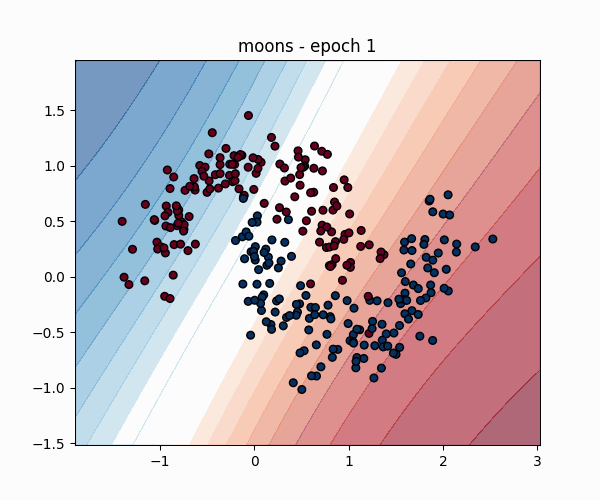

Final acc: 0.8466666666666667


In [15]:
# Example run:
model, history, gif_path = train_and_visualize(data="moons", epochs=400, n_hidden=8, lr=0.1)
